In [1]:
import numpy as np

In [4]:
def softmax(z):
    """
    Compute the softmax of a 2D numpy array along the specified axis.
    Parameters:
    z (numpy.ndarray): Input array of shape (m, n) where m is the number of samples
    and n is the number of classes.
    Returns:
    numpy.ndarray: Softmax probabilities of the same shape as input (m, n), where
    each row sums to 1 and represents the probability distribution
    over classes for a sample.
    Notes:
    - Applies a normalization trick to prevent numerical instability by subtracting
    the max value in each row before exponentiation.
    """
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [5]:
def test_softmax():
    test_cases = [
        (np.array([[0, 0, 0]]), "All zeros"),
        (np.array([[1, 2, 3]]), "Simple case"),
        (np.array([[1000, 1000, 1000]]), "Large identical values"),
        (np.array([[-1000, -1000, -1000]]), "Small identical values"),
        (np.array([[1, 0, -1]]), "Mixed positive and negative")
    ]
    for i, (z, description) in enumerate(test_cases):
        print(f"Test {i+1}: {description}")
        result = softmax(z)
        assert np.allclose(result.sum(axis=1), 1), f"Failed: Probabilities do not sum to 1 in {description}"
        assert np.all(result >= 0), f"Failed: Negative probabilities in {description}"
        print("Passed.")
    print("All tests passed for softmax function.")

test_softmax()

Test 1: All zeros
Passed.
Test 2: Simple case
Passed.
Test 3: Large identical values
Passed.
Test 4: Small identical values
Passed.
Test 5: Mixed positive and negative
Passed.
All tests passed for softmax function.


In [6]:
def loss_softmax(y_true, y_pred):
    """
    Compute categorical cross-entropy loss for a single observation.
    Parameters:
        y_true (ndarray): One-hot true labels (c,)
        y_pred (ndarray): Predicted probabilities (c,)
    Returns:
        float: Cross-entropy loss
    """
    return -np.sum(y_true * np.log(y_pred + 1e-10))

In [7]:
def test_loss_softmax():
    y_true = np.array([0, 1, 0])
    y_pred = np.array([0.1, 0.8, 0.1])
    expected_loss = -np.log(0.8)
    assert np.isclose(loss_softmax(y_true, y_pred), expected_loss), "Test Case 1 Failed"

    y_true = np.array([1, 0, 0])
    y_pred = np.array([0.3, 0.4, 0.3])
    expected_loss = -np.log(0.3)
    assert np.isclose(loss_softmax(y_true, y_pred), expected_loss), "Test Case 2 Failed"

    y_true = np.array([0, 1, 0])
    y_pred = np.array([0.01, 0.98, 0.01])
    expected_loss = -np.log(0.98)
    assert np.isclose(loss_softmax(y_true, y_pred), expected_loss), "Test Case 3 Failed"

    print("All test cases passed for loss_softmax!")

test_loss_softmax()

All test cases passed for loss_softmax!


In [8]:
def cost_softmax(X, y, W, b):
    """
    Compute average categorical cross-entropy cost over all samples.
    Parameters:
        X (ndarray): Feature matrix (n, d)
        y (ndarray): One-hot true labels (n, c)
        W (ndarray): Weight matrix (d, c)
        b (ndarray): Bias vector (c,)
    Returns:
        float: Average cost
    """
    n, d = X.shape
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return -np.sum(y * np.log(y_pred + 1e-10)) / n

In [9]:
def test_cost_softmax():
    X = np.array([[1, 2], [2, 3], [3, 4]])
    y = np.array([[1, 0], [0, 1], [1, 0]])
    W = np.array([[1, -1], [-1, 1]])
    b = np.array([0, 0])
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    expected_cost = -np.sum(y * np.log(y_pred + 1e-10)) / X.shape[0]
    assert np.isclose(cost_softmax(X, y, W, b), expected_cost), "Test Case 1 Failed"

    X = np.array([[1, 0], [0, 1], [1, 1]])
    y = np.array([[1, 0], [0, 1], [1, 0]])
    W = np.zeros((2, 2))
    b = np.zeros(2)
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    expected_cost = -np.sum(y * np.log(y_pred + 1e-10)) / X.shape[0]
    assert np.isclose(cost_softmax(X, y, W, b), expected_cost), "Test Case 2 Failed"

    print("All test cases passed for cost_softmax!")

test_cost_softmax()

All test cases passed for cost_softmax!


In [10]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute gradients of cost function w.r.t weights and biases.
    """
    n, d = X.shape
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n
    return grad_W, grad_b


In [11]:
def test_compute_gradient_softmax():
    X = np.array([[1, 2], [3, 4]])
    y = np.array([[1, 0], [0, 1]])
    W = np.array([[0.1, 0.2], [0.3, 0.4]])
    b = np.array([0.01, 0.02])
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W_expected = np.dot(X.T, (y_pred - y)) / X.shape[0]
    grad_b_expected = np.sum(y_pred - y, axis=0) / X.shape[0]
    grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
    assert np.allclose(grad_W, grad_W_expected, atol=1e-6), "Gradient W mismatch"
    assert np.allclose(grad_b, grad_b_expected, atol=1e-6), "Gradient b mismatch"
    print("All tests passed for compute_gradient_softmax!")

test_compute_gradient_softmax()


All tests passed for compute_gradient_softmax!


In [12]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize weights and biases.
    """
    cost_history = []
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
        W -= alpha * grad_W
        b -= alpha * grad_b
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")
    return W, b, cost_history


In [13]:
X = np.array([[1, 2], [2, 3], [3, 4]])
y = np.array([[1, 0], [0, 1], [1, 0]])
W = np.zeros((X.shape[1], y.shape[1]))
b = np.zeros(y.shape[1])
alpha = 0.1
n_iter = 500

W_opt, b_opt, cost_hist = gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=True)
print("Optimized W:", W_opt)
print("Optimized b:", b_opt)
print("Final cost:", cost_hist[-1])

Iteration 0: Cost = 0.644539
Iteration 100: Cost = 0.637800
Iteration 200: Cost = 0.636906
Iteration 300: Cost = 0.636634
Iteration 400: Cost = 0.636551
Iteration 499: Cost = 0.636526
Optimized W: [[-0.10705903  0.10705903]
 [ 0.11305002 -0.11305002]]
Optimized b: [ 0.22010905 -0.22010905]
Final cost: 0.6365257252185855


Gradient descent softmax test PASSED!


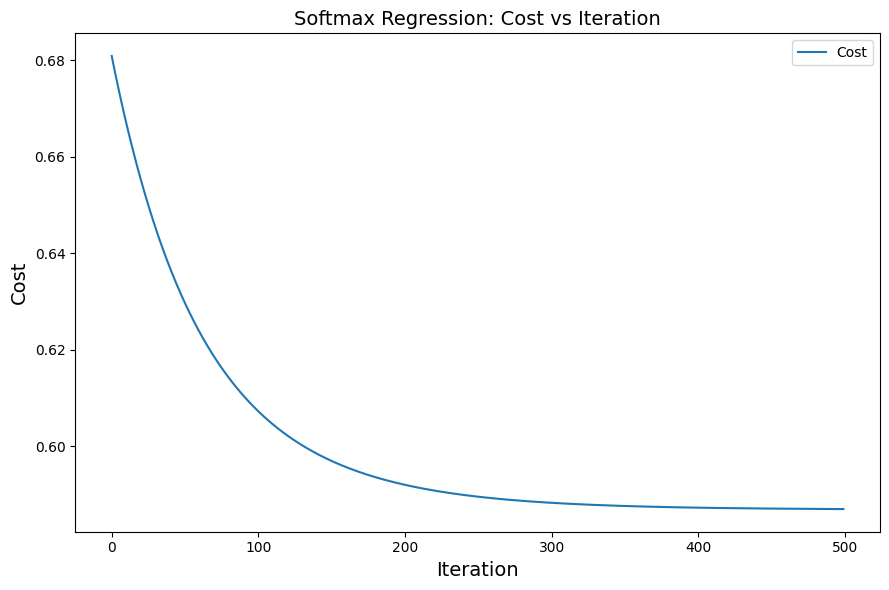

In [14]:
import matplotlib.pyplot as plt

def test_gradient_descent_softmax_with_plot():
    X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
    y = np.array([[1, 0], [0, 1], [1, 0], [0, 1]])

    W = np.zeros((X.shape[1], y.shape[1]))
    b = np.zeros(y.shape[1])
    alpha = 0.1
    n_iter = 500

    W_out, b_out, cost_history = gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False)

    assert len(cost_history) == n_iter, "Cost history length mismatch"
    assert W_out.shape == W.shape, "Weight shape mismatch"
    assert b_out.shape == b.shape, "Bias shape mismatch"
    assert cost_history[-1] < cost_history[0], f"Cost did not decrease: {cost_history[0]} -> {cost_history[-1]}"

    print("Gradient descent softmax test PASSED!")

    plt.figure(figsize=(9, 6))
    plt.plot(cost_history, label="Cost")
    plt.xlabel("Iteration", fontsize=14)
    plt.ylabel("Cost", fontsize=14)
    plt.title("Softmax Regression: Cost vs Iteration", fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()

test_gradient_descent_softmax_with_plot()

In [15]:
def predict_softmax(X, W, b):
    """
    Predict class labels using trained Softmax Regression parameters.
    Parameters:
        X (ndarray): Feature matrix (n, d)
        W (ndarray): Weight matrix (d, c)
        b (ndarray): Bias vector (c,)
    Returns:
        y_pred (ndarray): Predicted class labels (n,)
    """
    z = np.dot(X, W) + b
    y_prob = softmax(z)
    y_pred = np.argmax(y_prob, axis=1)
    return y_pred

In [16]:
def test_predict_softmax():
    X = np.array([[1, 2], [2, 3], [3, 4]])
    y = np.array([0, 1, 0])
    W = np.array([[1, -1], [-1, 1]])
    b = np.array([0, 0])

    y_pred = predict_softmax(X, W, b)
    print("Predicted labels:", y_pred)

    assert y_pred.shape == (X.shape[0],), "Prediction shape mismatch"
    assert np.all((y_pred == 0) | (y_pred == 1)), "Predictions must be 0 or 1"
    print("test_predict_softmax PASSED!")

test_predict_softmax()

Predicted labels: [1 1 1]
test_predict_softmax PASSED!


In [17]:
def evaluate_classification(y_true, y_pred):
    """
    Compute confusion matrix, precision, recall, and F1-score for multi-class classification.
    Parameters:
        y_true (ndarray): Ground truth labels (n,)
        y_pred (ndarray): Predicted labels (n,)
    Returns:
        metrics (dict): Confusion matrix, precision, recall, F1-score
    """
    classes = np.unique(np.concatenate((y_true, y_pred)))
    K = len(classes)

    confusion_matrix = np.zeros((K, K), dtype=int)
    for i in range(len(y_true)):
        confusion_matrix[y_true[i], y_pred[i]] += 1

    if K == 2:
        TP = confusion_matrix[1, 1]
        TN = confusion_matrix[0, 0]
        FP = confusion_matrix[0, 1]
        FN = confusion_matrix[1, 0]

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    else:
        precision, recall, f1_score = [], [], []
        for k in range(K):
            TP = confusion_matrix[k, k]
            FP = confusion_matrix[:, k].sum() - TP
            FN = confusion_matrix[k, :].sum() - TP
            prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
            rec = TP / (TP + FN) if (TP + FN) > 0 else 0.0
            f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
            precision.append(prec)
            recall.append(rec)
            f1_score.append(f1)
        precision = np.mean(precision)
        recall = np.mean(recall)
        f1_score = np.mean(f1_score)

    metrics = {
        "confusion_matrix": confusion_matrix,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }
    return metrics

In [18]:
y_true = np.array([0, 1, 0, 1, 1])
y_pred = np.array([0, 1, 0, 0, 1])

metrics = evaluate_classification(y_true, y_pred)
print("Confusion Matrix:\n", metrics["confusion_matrix"])
print("Precision:", metrics["precision"])
print("Recall:", metrics["recall"])
print("F1-score:", metrics["f1_score"])

Confusion Matrix:
 [[2 0]
 [1 2]]
Precision: 1.0
Recall: 0.6666666666666666
F1-score: 0.8


In [19]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt


In [21]:
iris = load_iris()
X_df = pd.DataFrame(iris.data, columns=iris.feature_names)
y_series = pd.Series(iris.target, name="target")

print("Dataset Info:")
print(X_df.info())
print("\nDataset Description Before Cleaning:")
print(X_df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Dataset Description Before Cleaning:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.1

In [22]:
X = iris.data
y = iris.target
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

In [23]:
X_train, X_test, y_train, y_test_onehot = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

assert X_train_scaled.shape == (X_train.shape[0], X_train.shape[1]), "X_train_scaled shape mismatch"
assert X_test_scaled.shape  == (X_test.shape[0], X_test.shape[1]),   "X_test_scaled shape mismatch"
print("Shape assertions passed!")

Shape assertions passed!


In [24]:
num_classes  = y_train.shape[1]
num_features = X_train_scaled.shape[1]
W = np.zeros((num_features, num_classes))
b = np.zeros(num_classes)
alpha  = 0.1
n_iter = 1000

In [25]:
print("\nTraining Softmax Regression Model:")
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train_scaled, y_train, W, b, alpha, n_iter, show_cost=True
)


Training Softmax Regression Model:
Iteration 0: Cost = 1.006823
Iteration 100: Cost = 0.319428
Iteration 200: Cost = 0.251376
Iteration 300: Cost = 0.211741
Iteration 400: Cost = 0.185004
Iteration 500: Cost = 0.165744
Iteration 600: Cost = 0.151226
Iteration 700: Cost = 0.139898
Iteration 800: Cost = 0.130812
Iteration 900: Cost = 0.123360
Iteration 999: Cost = 0.117192


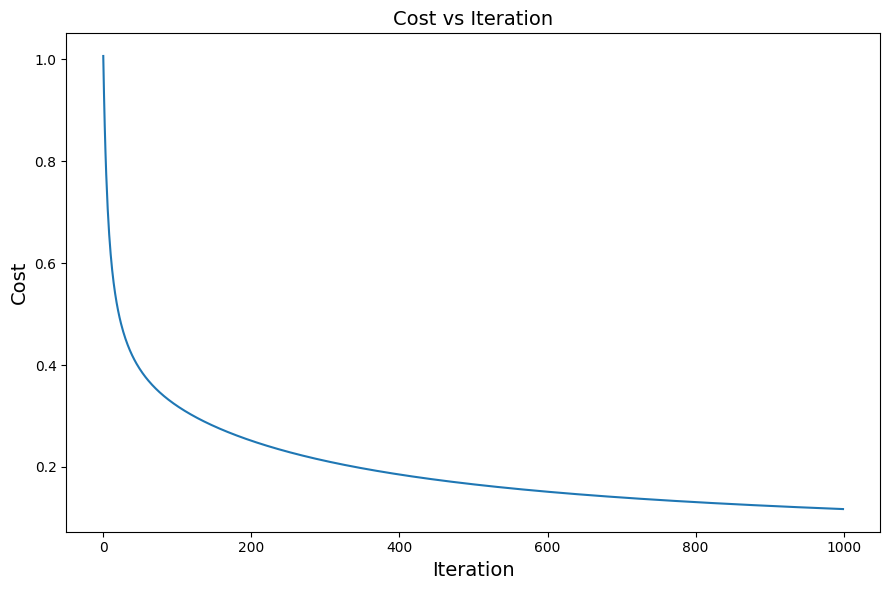

In [26]:
plt.figure(figsize=(9, 6))
plt.plot(cost_history)
plt.xlabel("Iteration", fontsize=14)
plt.ylabel("Cost", fontsize=14)
plt.title("Cost vs Iteration", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
train_cost = cost_softmax(X_train_scaled, y_train, W_opt, b_opt)
test_cost  = cost_softmax(X_test_scaled,  y_test_onehot, W_opt, b_opt)
print(f"\nTrain Loss (Cost): {train_cost:.4f}")
print(f"Test  Loss (Cost): {test_cost:.4f}")


Train Loss (Cost): 0.1172
Test  Loss (Cost): 0.1575


In [28]:
y_train_pred = predict_softmax(X_train_scaled, W_opt, b_opt)
y_test_pred  = predict_softmax(X_test_scaled,  W_opt, b_opt)
y_test_true  = np.argmax(y_test_onehot, axis=1)

test_accuracy = np.mean(y_test_pred == y_test_true) * 100
print(f"\nTest Accuracy: {test_accuracy:.2f}%")

metrics = evaluate_classification(y_test_true, y_test_pred)
cm = metrics["confusion_matrix"]
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {metrics['precision']:.2f}")
print(f"Recall:    {metrics['recall']:.2f}")
print(f"F1-Score:  {metrics['f1_score']:.2f}")



Test Accuracy: 93.33%

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
Precision: 0.93
Recall:    0.93
F1-Score:  0.93


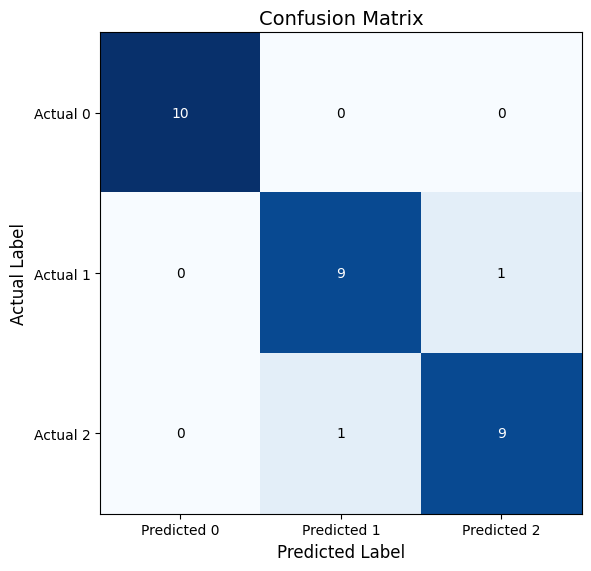

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm) / 2 else 'black')

plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()